1. Fetching street network for Wuse, Abuja, Nigeria...
2. Fetching existing AEDC power infrastructure (substations, lines)...
Note: No specific power tags found in this exact bounding box.
3. Rendering the Digital Twin Basemap...


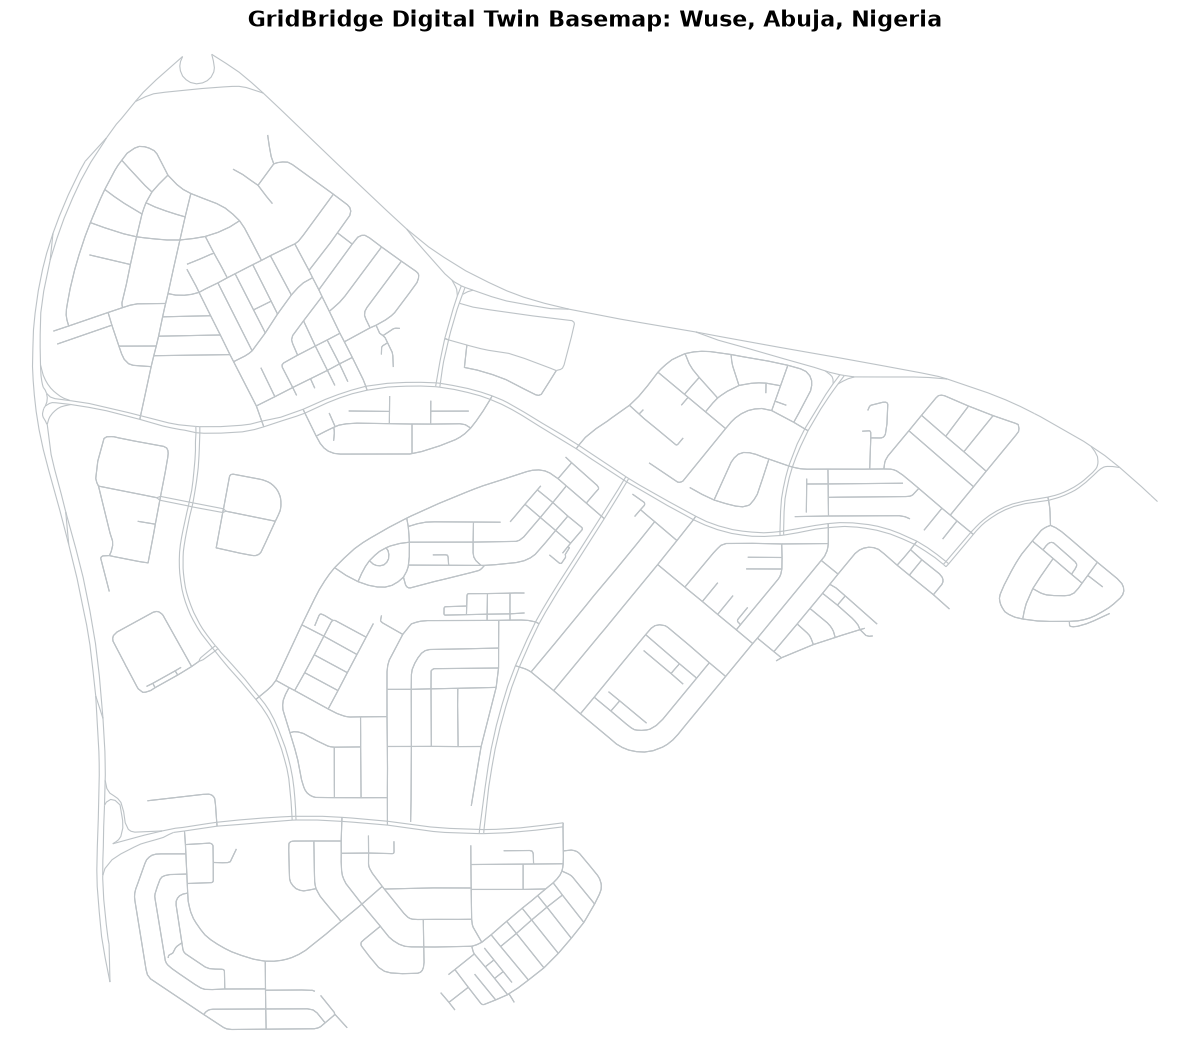

4. Saving spatial data to local directory...
✅ Phase 2 Complete: Spatial canvas downloaded and saved!


In [1]:
import osmnx as ox
import matplotlib.pyplot as plt
import os
import warnings

# Suppress minor geospatial warnings for a clean output
warnings.filterwarnings('ignore')

# 1. Define location (Using Wuse, Abuja for faster processing instead of the entire FCT)
place_name = "Wuse, Abuja, Nigeria"
print(f"1. Fetching street network for {place_name}...")

# 2. Download the physical street network
G = ox.graph_from_place(place_name, network_type='drive')

print("2. Fetching existing AEDC power infrastructure (substations, lines)...")
# 3. Download tagged electrical infrastructure from OSM
tags = {'power': ['substation', 'transformer', 'line']}
try:
    power_data = ox.features_from_place(place_name, tags=tags)
    found_power = True
except Exception as e:
    print("Note: No specific power tags found in this exact bounding box.")
    found_power = False

print("3. Rendering the Digital Twin Basemap...")
# 4. Plot the network and overlay power assets
fig, ax = plt.subplots(figsize=(12, 12), facecolor='white')

# Plot base street map
ox.plot_graph(G, ax=ax, node_size=0, edge_color='#bdc3c7', edge_linewidth=0.8, show=False, close=False)

# Overlay power infrastructure if it exists in the selected district
if found_power and not power_data.empty:
    points = power_data[power_data.geom_type == 'Point']
    lines = power_data[power_data.geom_type == 'LineString']
    
    if not points.empty:
        points.plot(ax=ax, color='#e74c3c', markersize=25, label='Transformers / Nodes', zorder=5)
    if not lines.empty:
        lines.plot(ax=ax, color='#2980b9', linewidth=2, label='Power Lines', zorder=4)
    ax.legend(fontsize=12, loc='upper right')

plt.title(f"GridBridge Digital Twin Basemap: {place_name}", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Save the data for the final VPP/Solar integration notebook
print("4. Saving spatial data to local directory...")
os.makedirs("../data/osm", exist_ok=True)
ox.save_graphml(G, "../data/osm/abuja_basemap.graphml")

print("✅ Phase 2 Complete: Spatial canvas downloaded and saved!")